# Exercises to Statistical Methods and Analysis Techniques in Experimental Physics
## Exercise 4, March 18th, 2025

# 1) Combining measurements

### $t\bar{t}$ cross section at $\sqrt{s} = 13.6\,$TeV

Both ATLAS and CMS have measured the cross section $\sigma(pp\rightarrow t\bar{t})$ at $\sqrt{s} = 13.6\,$TeV, where s should be the Mandelstam variable $-(p_1+p_2)^2$; in the CM frame it corresponds to the total energy squared.
The results are respectively $\sigma_{\rm{ATLAS}} = 850 \pm 3 (\rm{stat}) \pm 18 (\rm{syst}) \pm 20 (\rm{lumi})\,$pb ([Phys. Lett. B 848 (2024) 138376](https://doi.org/10.1016/j.physletb.2023.138376)) and $\sigma_{\rm{CMS}} = 881 \pm 23 (\rm{stat+syst}) \pm 20 (\rm{lumi})\,$pb ([JHEP 08 (2023) 204](https://doi.org/10.1007/JHEP08(2023)204)).

1. discuss the compatibility between the two results. Does it even make sense to combine them?

1. assuming that the uncertainties are gaussian and uncorrelated between both different components and different experiments, compute the estimate of $\sigma(pp\rightarrow t\bar{t})$ combining the results from ATLAS and CMS using the **Maximum Likelihood Method**

1. repeat the exercise above, now considering that the luminosity uncertainty is correlated between ATLAS and CMS. How do the combined value and its uncertainty change?

In [1]:
# 1.
data = {'atlas':{'value':850,
                 'error_sources':{'stat_err':3,
                                  'syst_err':18,
                                  'lumi_err':20},
                },

        'cms':{'value':881,
               'error_sources':{'stat_and_syst_err':23,
                                'lumi_err':20},
                },
       }

In [2]:
import numpy as np
from scipy.stats import chi2

weighted_mean = {'value':0,
                 'err':0,
                }

normalization = 0
for experiment in data:
    data[experiment]['err'] = 0
    for err_type in data[experiment]['error_sources']:
        data[experiment]['err'] += data[experiment]['error_sources'][err_type]**2
    data[experiment]['err'] = np.sqrt(data[experiment]['err'])
    
    normalization += 1/data[experiment]['err']**2    
    weighted_mean['value'] += data[experiment]['value']/data[experiment]['err']**2

weighted_mean['value'] = weighted_mean['value']/normalization
weighted_mean['err'] = np.sqrt(1/normalization)
weighted_mean['chi2'] = 0
for experiment in data:
    weighted_mean['chi2'] += (data[experiment]['value'] - weighted_mean['value'])**2/data[experiment]['err']**2
weighted_mean['red_chi2'] = weighted_mean['chi2']/len(data.keys())
weighted_mean['p-value'] = 1 - chi2.cdf( weighted_mean['chi2'], len(data.keys()) ) 

print(f'Given the small value of the reduced chi-squared {round(weighted_mean['red_chi2'],3)} and the high p-value {round(weighted_mean['p-value'],3)} \
of the weighted mean, it makes sense to average the two measurements as they are indeed compatible. The result is\n\
\tWeighted mean: {int(round(weighted_mean['value'],0))} pm {int(round(weighted_mean['err'],0))}')

Given the small value of the reduced chi-squared 0.289 and the high p-value 0.749 of the weighted mean, it makes sense to average the two measurements as they are indeed compatible. The result is
	Weighted mean: 864 pm 20


In [3]:
# 2.
from scipy.stats import norm
import matplotlib.pyplot as plt

means = np.linspace( min([data[experiment]['value'] for experiment in data])-20, max([data[experiment]['value'] for experiment in data])+20, int(1e4) ) 
L = []
for mean in means:
    L.append(1)
    for experiment in data:
        L[-1] *= norm.pdf( data[experiment]['value'], mean, data[experiment]['err'] ) # As standard deviation I am using the error on the value inferred experimentally
L = np.array(L)

index = np.argmax(L)
best_L = L[index]
MLE_mean = {'value':means[index]}
MLE_mean['chi2'] = 0
for experiment in data:
    MLE_mean['chi2'] += (data[experiment]['value'] - MLE_mean['value'])**2/data[experiment]['err']**2
MLE_mean['red_chi2'] = MLE_mean['chi2']/len(data.keys())
MLE_mean['p-value'] = 1 - chi2.cdf( MLE_mean['chi2'], len(data.keys()) )

min_L = best_L*np.exp(-0.5)
i = 0
while L[index+i] > min_L:
    i += 1
right_bound = means[index+i]
i = 0
while L[index-i] > min_L:
    i += 1
left_bound = means[index-i]
MLE_mean['err'] = max( right_bound-MLE_mean['value'], MLE_mean['value'] - left_bound )

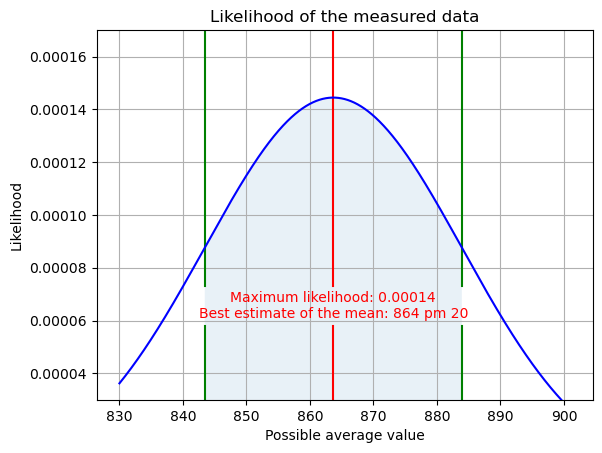

The difference between the weighted mean and the mean evaluated with the maximum likelihood method is
	(weighted mean)-(maximum likelihood mean) = 0.0005
The p-values of the two esitmates are
   Maximum Likelihood Estimate: 0.7489
                 Weighted mean: 0.7489
 The two results are identical.


In [4]:
plt.grid(1)
plt.title('Likelihood of the measured data')
plt.ylabel('Likelihood')
plt.xlabel('Possible average value')

plt.text(MLE_mean['value'],0.000061,f'Maximum likelihood: {round(best_L,5)}\nBest estimate of the mean: {round(MLE_mean['value'])} pm {int(round(MLE_mean['err']))}', color='red', ha='center')
plt.plot((MLE_mean['value'], MLE_mean['value']), (0.00003,0.000058), color='r')
plt.plot((MLE_mean['value'], MLE_mean['value']), (0.000073, 0.00017), color='r')

plt.plot((MLE_mean['value']+MLE_mean['err'], MLE_mean['value']+MLE_mean['err']), (0.00003,0.000058), color='g')
plt.plot((MLE_mean['value']+MLE_mean['err'], MLE_mean['value']+MLE_mean['err']), (0.000073, 0.00017), color='g')

plt.plot((MLE_mean['value']-MLE_mean['err'], MLE_mean['value']-MLE_mean['err']), (0.00003,0.000058), color='g')
plt.plot((MLE_mean['value']-MLE_mean['err'], MLE_mean['value']-MLE_mean['err']), (0.000073, 0.00017), color='g')

shaded_region = means[(means>MLE_mean['value']-MLE_mean['err']) & (means<MLE_mean['value']+MLE_mean['err'])]
shaded_curve = L[(means>MLE_mean['value']-MLE_mean['err']) & (means<MLE_mean['value']+MLE_mean['err'])]
plt.fill_between(shaded_region, np.zeros(len(shaded_region)), shaded_curve, alpha=0.1)

plt.plot(means, L, zorder=3, color='blue')
plt.ylim([0.00003, 0.00017])
plt.show()

print(f'The difference between the weighted mean and the mean evaluated with the maximum likelihood method is\n\
\t(weighted mean)-(maximum likelihood mean) = {round(weighted_mean['value'] - MLE_mean['value'],4)}\n\
The p-values of the two esitmates are\n',\
'Maximum Likelihood Estimate:'.rjust(30),f'{round(MLE_mean['p-value'],4)}\n',\
'Weighted mean:'.rjust(30),f'{round(weighted_mean['p-value'],4)}\n',\
'The two results are identical.')

In [5]:
# 3.
# The different errors that affect a measurement (stat, syst and lumi) can be seen as three random variables, all having mean
# equal to zero and standard deviation equal to stat_err, syst_err and lumi_err. Take just two of them for a simple visualization:
# we have stat defining a gaussian along the x axis, and lumi along the y axis. Their composite distribution in 2D is the product
# of the two gaussian: G(x,0,stat_err)*G(y,0,lumi_err). When they are uncorrelated, this results in an ellissoidal-gaussian that
# is not rotated. When they are correlated, this ellissoidal-gaussian is rotated. Usually we look at the distribution of their sum,
# z, we know it is again a gaussian with mean=0+0 and variance=stat_err**2+lumi_err**2 ! Graphically, G(z,0,z_err) is obtained
# integrating the composite distribution along the lines x+y=z where, z is the actual error that affects the measurement.
#
# If we now assume the lumi to be correlated in the two experiment, I understand that the random variable 'lumi', which is gaussian
# distributed around 0 with std lumi_err, takes the same value in both experiments. Than, what we obtain is a pdf of two random
# variables together: the two experimental results. The ATLAS suffers from its individual stat_and_syst_err and from the shared
# lumi_err, the CMS is affected by the shared lumi_err and its own sta_and_syst_err.
#
# So, given a possible value for the mean, its likelihood has to be computed as follows: |mean-ATLAS|=stat_and_syst_ATLAS+lumi_err
# |mean-CMS|=stat_and_syst_CMS+lumi_err. Then the likelihood is obtained as
#                            L = pdf(stat_and_syst_ATLAS)*pdf(stat_and_syst_CMS)*pdf(lumi_err)
# Of course, we have to account for all the possible combinations of the values of individual error sources that yield the same
# overall error. 

data['atlas']['error_sources']['stat_and_syst_err'] = (data['atlas']['error_sources']['stat_err']**2 + data['atlas']['error_sources']['syst_err']**2)**0.5

lumi_err_step = 0.1
means = np.linspace( min([data[experiment]['value'] for experiment in data])-20, max([data[experiment]['value'] for experiment in data])+20, int(1e3) )
L = []
for mean in means:
    total_err_ATLAS = abs(data['atlas']['value'] - mean)
    total_err_CMS = abs(data['cms']['value'] - mean)
    
    L.append(0)
    # Positive values of lumi_err
    lumi_err = 0
    while lumi_err < data['cms']['error_sources']['lumi_err']*3:
        L_contribution = norm.pdf(lumi_err, 0, data['cms']['error_sources']['lumi_err'])*norm.pdf(total_err_ATLAS-lumi_err, 0, data['atlas']['error_sources']['stat_and_syst_err'])*norm.pdf(total_err_CMS-lumi_err, 0, data['cms']['error_sources']['stat_and_syst_err'])
        L[-1] += L_contribution
        lumi_err += lumi_err_step # As we get further from 0, the contribution to L should decrease

    # Negative values of lumi_err
    lumi_err = 0
    while lumi_err > -data['cms']['error_sources']['lumi_err']*3:
        L_contribution = norm.pdf(lumi_err, 0, data['cms']['error_sources']['lumi_err'])*norm.pdf(total_err_ATLAS-lumi_err, 0, data['atlas']['error_sources']['stat_and_syst_err'])*norm.pdf(total_err_CMS-lumi_err, 0, data['cms']['error_sources']['stat_and_syst_err'])
        L[-1] += L_contribution
        lumi_err -= lumi_err_step # As we get further from 0, the contribution to L should decrease
L = np.array(L)

In [6]:
index = np.argmax(L)
best_L = L[index]
MLE_mean = {'value':means[index]}
MLE_mean['chi2'] = 0
for experiment in data:
    MLE_mean['chi2'] += (data[experiment]['value'] - MLE_mean['value'])**2/data[experiment]['err']**2
MLE_mean['red_chi2'] = MLE_mean['chi2']/len(data.keys())
MLE_mean['p-value'] = 1 - chi2.cdf( MLE_mean['chi2'], len(data.keys()) )

min_L = best_L*np.exp(-0.5)
i = 0
while L[index+i] > min_L:
    i += 1
right_bound = means[index+i]
i = 0
while L[index-i] > min_L:
    i += 1
left_bound = means[index-i]
MLE_mean['err'] = max( right_bound-MLE_mean['value'], MLE_mean['value'] - left_bound )

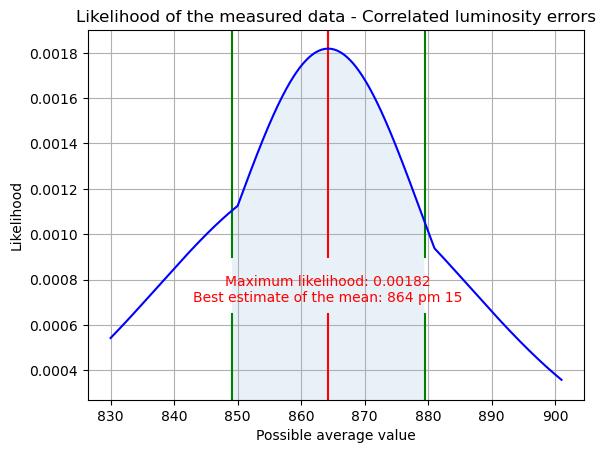

The difference between the weighted mean and the mean evaluated with the maximum likelihood method is
	(weighted mean)-(maximum likelihood mean) = -0.5842
The p-values of the two esitmates are
   Maximum Likelihood Estimate: 0.7486
                 Weighted mean: 0.7489
 The weighted mean has a slightly higher p-vaue. The MLE has lower uncertainty.


In [7]:
plt.grid(1)
plt.title('Likelihood of the measured data - Correlated luminosity errors')
plt.ylabel('Likelihood')
plt.xlabel('Possible average value')

plt.text(MLE_mean['value'],0.0007,f'Maximum likelihood: {round(best_L,5)}\nBest estimate of the mean: {round(MLE_mean['value'])} pm {int(round(MLE_mean['err']))}', color='red', ha='center')
plt.plot((MLE_mean['value'], MLE_mean['value']), (0.00025,0.00065), color='r')
plt.plot((MLE_mean['value'], MLE_mean['value']), (0.0009, 0.002), color='r')

plt.plot((MLE_mean['value']+MLE_mean['err'], MLE_mean['value']+MLE_mean['err']), (0.00025,0.00065), color='g')
plt.plot((MLE_mean['value']+MLE_mean['err'], MLE_mean['value']+MLE_mean['err']), (0.0009, 0.002), color='g')

plt.plot((MLE_mean['value']-MLE_mean['err'], MLE_mean['value']-MLE_mean['err']), (0.00025,0.00065), color='g')
plt.plot((MLE_mean['value']-MLE_mean['err'], MLE_mean['value']-MLE_mean['err']), (0.0009, 0.002), color='g')

shaded_region = means[(means>MLE_mean['value']-MLE_mean['err']) & (means<MLE_mean['value']+MLE_mean['err'])]
shaded_curve = L[(means>MLE_mean['value']-MLE_mean['err']) & (means<MLE_mean['value']+MLE_mean['err'])]
plt.fill_between(shaded_region, np.zeros(len(shaded_region)), shaded_curve, alpha=0.1)

plt.plot(means, L, zorder=3, color='blue')
plt.ylim([0.00027, 0.0019])
plt.show()

print(f'The difference between the weighted mean and the mean evaluated with the maximum likelihood method is\n\
\t(weighted mean)-(maximum likelihood mean) = {round(weighted_mean['value'] - MLE_mean['value'],4)}\n\
The p-values of the two esitmates are\n',\
'Maximum Likelihood Estimate:'.rjust(30),f'{round(MLE_mean['p-value'],4)}\n',\
'Weighted mean:'.rjust(30),f'{round(weighted_mean['p-value'],4)}\n',\
'The weighted mean has a slightly higher p-vaue. The MLE has lower uncertainty.')


# 2) 2D max likelihood fit

An experiment recorded 20 events of the process $\mathrm{B}_{\mathrm{s}}\to \mu^\pm\mu^\mp$.
Two observables are measured, the dimuon invariant mass and the decay length, i.e. the distance travelled by the $\mathrm{B}_{\mathrm{s}}$ meson before decaying. The data are reported below, the mass is given in MeV and the decay length in millimiters.
The mass experimental resolution is 30 MeV and constant for all events, the instrinsic width of the $\mathrm{B}_{\mathrm{s}}$ meson is negligible relative to experimental resolution.

```
           mass  decay_length
0   5342.990629      0.129966
1   5370.098405      0.313469
2   5391.762131      0.951778
3   5373.248764      0.157752
4   5421.216001      0.303553
5   5378.464940      0.068252
6   5413.543450      0.547077
7   5330.830304      0.306358
8   5399.754153      0.354952
9   5395.380538      0.029269
10  5395.408818      0.882227
11  5384.344397      0.410669
12  5395.233445      0.348704
13  5342.018296      0.010897
14  5348.767873      0.917650
15  5311.968224      1.828611
16  5303.544724      0.076058
17  5415.554657      0.537094
18  5394.132595      0.873480
19  5371.808143      0.573051
```
1. plot the 1D projections and 2D distributions. Are the two observables correlated? (this of the implication on the combined 2D pdf)
1. perform a 2-dimensional maximum likelihood fit to mass and decay length, following the example shown during lecture https://mdonega.github.io/hep-datanalysis-jb/interactive-nbs/MLMethod.html#interactive-example-ml-method-mean-of-a-gaussian
    1. to find the minimum of the negative log likelihood, performance a grid search with 10, 100, 1000 steps per axis (is this computationally efficient?). The initial scan ranges are 5000-5500 MeV and 0.1-1 mm (you can refine and tighten them after a first coarse scan)
    3. find the minimum NLL using `scipy.optimize.minimize`. Notice there exist several minimization algorithms, most do gradient descent some don't. Experiment yourself [docs](https://docs.scipy.org/doc/scipy/tutorial/optimize.html)
    4. tune the initial fit parameters and parameter ranges sensibly, otherwise the minimization won't converge. Use the distributions you plotted in the beginning for guidance.
3. compare the so found best-fit mass and lifetime to the values found in literature (use https://pdglive.lbl.gov/Viewer.action assume the heavy $\mathrm{B}_\mathrm{s}$ eigenstate)
4. compare the best-fit mass to the estimator of the mean of the dataset

Nota bene: the actual decay length is $L = \beta \gamma c t$, where $\beta$ and $\gamma$ are the particle velocity and Lorentz factor respectively, and $t$ is the decay time. For simplicity, albeit incorrect from a physics standpoint, assume $\beta=\gamma=1$. We call "lifetime" the decay constant of the exponential decay $e^{-t/\tau}$, or, correspondingly $e^{-L/c\tau}$

# 3) Extended PDF

Before moving to a more realistic example (next exercise), let's implement an _extended_ ML fit to a simple normally distributed dataset.
That is, not only we want to estimate the mean and width of the normal distribution, we also want to estimate the yield.

1. generate 1000 normally distributed events, with $\mu=0$ and $\sigma=1$
2. write the extended NLL (hint: remember we want to _minimize_ the ENLL, are all terms needed?)
3. fit using `scipy.optimize.minimize` to estimate $N$, $\mu$, $\sigma$, where $N$ is the number of events
    1. be careful with initial parameters (don't pass it the exact parameters you used for generation, but don't give it nonsense numbers either)
    2. notice that $\sigma$ cannot be negative ==> you need to impose bounds 
5. estimate the uncertainties from the covariance matrix (hint: remember how it is related to the hessian. Hint: might need packages that do numerical derivative)
    1. what uncertainty do you expect for $N$?

# 4) Realistic case, extended fit, signal and background  

In this exercise you'll experiment with a realistic example similar to the simpler one discussed in exercise 2.  

The dataset `data.csv` contains the values of mass and decay length for signal which can be either signal or background.

1. load the dataset and plot 1D and 2D distributions
2. perform an extended max-likelihood fit to the 2D distribution mass x decay length
    1. the proportion between signal and background is unknown, but the total S + B yield must correspond to the number of events
    2. from the plotted distributions, make an educated guess on which PDFs to use for signal and background
    3. be careful with parameter bounds and initial guesses. This fit is more finicky than before...
    4. what's more, you might have to play with the minimizer's parameters, such that tolerance and gradient step size
    5. if the parameters have very different scales, this can create numerical instabilities (hint: to help convergencency, you might have to scale some parameters)
3. redo the 1D and 2D plots, overlay the fitted S+B function as well as the S and B components separately
4. estimate the uncertainties
5. "corner plot": plot all pairwise 2D NLL scans as well as the 1D marginal scans. Discuss whether any variables are correlated and try to explain why that happens by relating our observations to the characteristics of the 1D and 2D plots